In [166]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.collections import PatchCollection
from matplotlib.patches import Polygon
import time

In [ ]:
def calculate_closeness_criterion(C1, C2, d0):
    # c1_min and c1_max are the boundaries on axis e1_hat, the rectangle edge direction vector (same goes for e2_hat)
    c1_max = np.max(C1)
    c1_min = np.min(C1)
    c2_max = np.max(C2)
    c2_min = np.min(C2)

    D1 = np.minimum(c1_max - C1, C1 - c1_min)
    D2 = np.minimum(c2_max - C2, C2 - c2_min)

    d = np.maximum(np.minimum(D1, D2), d0)

    return np.sum(1.0 / d)

def fit_rectangle(cluster, d0):
    # the inputs into the criterion functions are C1 and C2 which are the projections of all the range points on the two orthogonal edges determined by theta
    thetas = np.linspace(0, 90, 89, endpoint=False) * np.pi / 180
    q_max = 0
    optimal_theta = 0
    for theta in thetas:
        # rectangle edge direction vectors
        e1_hat = np.array([np.cos(theta), np.sin(theta)])
        e2_hat = np.array([-np.sin(theta), np.cos(theta)])

        # projections on to the edge
        C1 = np.dot(cluster, e1_hat)
        C2 = np.dot(cluster, e2_hat)

        q = calculate_closeness_criterion(C1, C2, d0)
        if q > q_max: 
            q_max = q
            optimal_theta = theta
    
    # with the optimal rectangle angle determined, we can now reconstruct the rectangle
    e1 = np.array([np.cos(optimal_theta), np.sin(optimal_theta)])
    e2 = np.array([-np.sin(optimal_theta), np.cos(optimal_theta)])

    C1 = cluster @ e1
    C2 = cluster @ e2

    c1_min = np.min(C1)
    c1_max = np.max(C1)
    c2_max = np.max(C2)
    c2_min = np.min(C2)

    e1 = np.array([np.cos(optimal_theta), np.sin(optimal_theta)])
    e2 = np.array([-np.sin(optimal_theta), np.cos(optimal_theta)])

    rectangle_corners = np.array([
        c1_min * e1 + c2_min * e2,
        c1_max * e1 + c2_min * e2,
        c1_max * e1 + c2_max * e2,
        c1_min * e1 + c2_max * e2
    ])
    return rectangle_corners

fitting time: 0.0015630722045898438 seconds
fitting time: 0.0015354156494140625 seconds
fitting time: 0.001528024673461914 seconds


C:\Users\admin-pc\AppData\Local\Temp\ipykernel_62188\1779802087.py:9: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  points.append(np.random.multivariate_normal(means[i], covs[i], 1000))


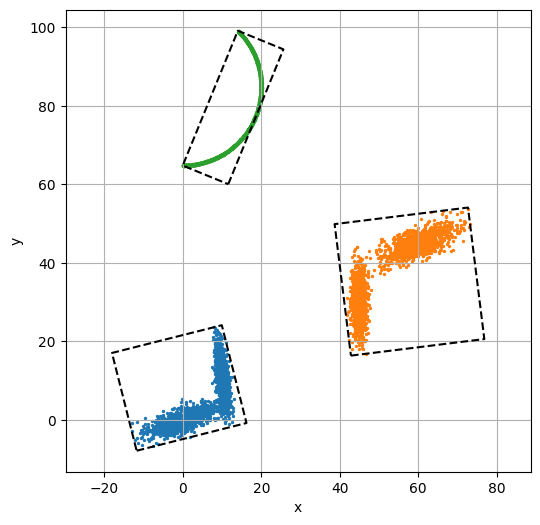

In [174]:
# testing the object clustering and rectangle fitting

# manually create the L-shape corners a 2D LiDAR might see by generate gaussians close to each other in a sort of L shape
means = np.array([[0, 0], [10, 11], [60, 45], [45, 30]])
covs = np.array([[[20, 8], [8, 1]], [[1, -4], [-2, 20]], [[20, 10], [10, 1]], [[1, 0], [0, 20]]])

points = []
for i in range(len(means)):
    points.append(np.random.multivariate_normal(means[i], covs[i], 1000))

# generate a semicircle perimeter that a 2D LiDAR might see
def generate_semicircle(center, radius, num_points):
    theta = np.linspace(0, -np.pi + np.deg2rad(45), num_points)

    r = radius + np.random.normal(0, 0.05, num_points)

    x = center[0] + r * np.cos(theta)
    y = center[1] + r * np.sin(theta)

    return np.column_stack((x, y))

# rotate the circle as desired
def rotate(points, angle):
    R = np.array([
        [np.cos(angle), -np.sin(angle)],
        [np.sin(angle),  np.cos(angle)]
    ])

    return points @ R.T

semicircle = generate_semicircle(
    center=(60, 60),
    radius=20,
    num_points=2000
)

semicircle = rotate(semicircle, np.deg2rad(45))

# group all the clusters of points into one clusters array
clusters = np.array([np.concatenate((points[0], points[1])), np.concatenate((points[2], points[3])), semicircle])

plt.figure(figsize=(6, 6))
for cluster in clusters:
    start_time = time.time()
    rectangle_corners = fit_rectangle(cluster, d0=5) # test the rectangular fitting algorithm
    end_time = time.time()
    print('fitting time:', end_time-start_time, 'seconds')

    x_coords = [rectangle_corners[0][0], rectangle_corners[1][0], rectangle_corners[2][0], rectangle_corners[3][0], rectangle_corners[0][0]]
    y_coords = [rectangle_corners[0][1], rectangle_corners[1][1], rectangle_corners[2][1], rectangle_corners[3][1], rectangle_corners[0][1]]

    plt.plot(x_coords, y_coords, linestyle='--', color='black')
    plt.scatter(cluster[:,0], cluster[:,1], s=2)
plt.axis("equal")
plt.xlabel('x')
plt.ylabel('y')
plt.grid('both')
plt.show()